# Data Storytelling Example: Quality of Life Scores
Let's do an example of data storytelling by using an API to get quality of life scores for major urban areas like Shanghai. Reasons why we might be interested in quality of life for major urban areas include:
* Explore places to move/relocate
* Explore places to work/start a company
* Etc...

Some aspects of quality of life we are personally interested in:
* Resources available
* Climate/weather
* Cost of living
* Education
* Safety/crime rate
* Etc...

We can get this information from an API like the [Teleport API](https://developers.teleport.org/). From the website:
>We're building the largest and most up-to-date quality of life database for Planet Earth using 300+ different data dimensions from 70+ different sources, all updated periodically. Our global sources include the World Bank, World Health Organization, United Nations, Reporters Without Borders, OpenStreetMap, GeoNames, OpenFlights, Heritage Foundation, AngelList, Airbnb, Seed-DB and others. On top of these we augment the sets with things like laws and regulations, real estate prices and recruitment market data from local sources from countries around the world.

## Proof of Concept: Shanghai
Let's see if we can get the API to work for Shanghai's quality of living scores. If we can get this to work for Shanghai, then we can get it to work for other urban areas, perhaps as part of a comparison. 

Using the `GET /urban_areas/{ua_id}/scores/` endpoint, we can the scores for Shanghai. This endpoint has one required parameter, `ua_id`, which is `slug:shanghai`. You can find the `ua_id` for an urban area via the `GET /urban_areas/` end point.

### Make the Request

In [1]:
import requests

url = "https://api.teleport.org/api"
url += "/urban_areas/slug:shanghai/scores/"

response = requests.get(url)
print(response.text) 

{"_links":{"curies":[{"href":"https://developers.teleport.org/api/resources/Location/#!/relations/{rel}/","name":"location","templated":true},{"href":"https://developers.teleport.org/api/resources/City/#!/relations/{rel}/","name":"city","templated":true},{"href":"https://developers.teleport.org/api/resources/UrbanArea/#!/relations/{rel}/","name":"ua","templated":true},{"href":"https://developers.teleport.org/api/resources/Country/#!/relations/{rel}/","name":"country","templated":true},{"href":"https://developers.teleport.org/api/resources/Admin1Division/#!/relations/{rel}/","name":"a1","templated":true},{"href":"https://developers.teleport.org/api/resources/Timezone/#!/relations/{rel}/","name":"tz","templated":true}],"self":{"href":"https://api.teleport.org/api/urban_areas/slug:shanghai/scores/"}},"categories":[{"color":"#f3c32c","name":"Housing","score_out_of_10":5.744},{"color":"#f3d630","name":"Cost of Living","score_out_of_10":7.179},{"color":"#f4eb33","name":"Startups","score_out_

## Parse the JSON
Now that we have the request response, lets parse it for category name: score pairs.

In [2]:
import json
import pandas as pd

json_obj = json.loads(response.text)
print(json_obj.keys())
cat_ser = pd.Series(dtype=float)
for category_obj in json_obj["categories"]:
    name = category_obj["name"]
    score = category_obj["score_out_of_10"]
    # print(name, ":", score)
    cat_ser[name] = score
print(cat_ser)

dict_keys(['_links', 'categories', 'summary', 'teleport_city_score'])
Housing                  5.744000
Cost of Living           7.179000
Startups                 5.725500
Venture Capital          9.288000
Travel Connectivity      6.862000
Commute                  5.084500
Business Freedom         3.895667
Safety                   7.208500
Healthcare               5.145000
Education                5.699500
Environmental Quality    2.838750
Economy                  6.103000
Taxation                 1.496000
Internet Access          2.636000
Leisure & Culture        6.693500
Tolerance                2.741000
Outdoors                 5.717500
dtype: float64


### Visualize the Scores
Let's visualize the scores as a bar chart. The x-axis will be the categories (discrete) and the y-axis will be the scores (out of 10).

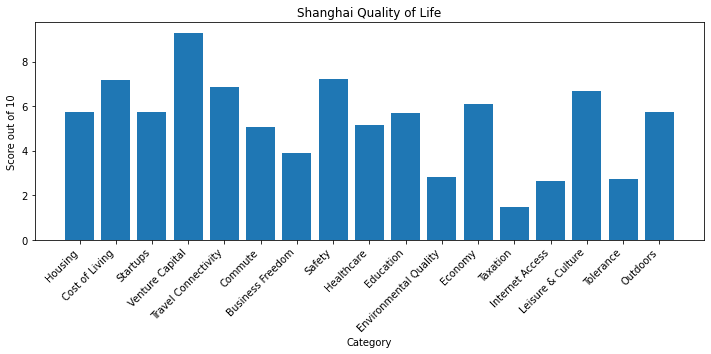

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(cat_ser.index, cat_ser)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Category")
plt.ylabel("Score out of 10")
plt.title("Shanghai Quality of Life")
plt.show()

### Insights
From the chart, it is clear Shanghai has some strengths and weaknesses for quality of life.

Strengths:
* Cost of living
* Venture capital
* Travel connectivity
* Safety
* Etc.

Weaknesses
* Business freedom
* Taxation
* Tolerance

## Future Work
Now that we have a proof of concept for Shanghai, future work would be to compare multiple cities and perhaps make a recommendation...